# STAGE 1: Data Preparation & Baseline Establishment
## Goal: Validate dataset quality and establish minimum performance baseline

baseline mean 
simplest possible model we can train first to establish a minimum performance benchmark. 

This notebook covers:
1. Loading and analyzing your WBAN Sybil detection dataset
2. Data quality checks (missing values, class distribution, outliers)
3. Training Logistic Regression as baseline model
4. Evaluating baseline performance
5. Making go/no-go decision for Stage 2

## Section 1: Import Libraries

Import all necessary Python libraries for data manipulation, preprocessing, and machine learning.

In [33]:
# Data manipulation
import pandas as pd
import numpy as np

# Machine learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Metrics and evaluation
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    roc_auc_score,
    f1_score,
    accuracy_score
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Warnings
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")

All libraries imported successfully


## Section 2: Load and Explore Dataset

Load your WBAN Sybil detection dataset and perform initial exploration.

**Expected CSV format:**
```
pps,rssi_mean,rssi_std,iat_mean,iat_std,...,label
45.2,78.5,5.3,12.1,2.1,...,0
50.1,80.2,4.1,11.5,1.9,...,0
200.5,20.3,15.2,45.3,10.2,...,1
```

Where:
- `label=0`: Normal traffic
- `label=1`: Sybil attack traffic

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
n1 = pd.read_csv("mixed.csv")
n2 = pd.read_csv("mixed_less_obvious.csv")
n3 = pd.read_csv("dataset_all_labeled1.csv")
n4 = pd.read_csv("dataset_all_labeled2.csv")
n5 = pd.read_csv("dataset_all_labeled3.csv")
n6 = pd.read_csv("dataset_all_labeled4.csv")
n7 = pd.read_csv("dataset_all_labeled5.csv")
n8 = pd.read_csv("dataset_all_labeled6.csv")
n9 = pd.read_csv("mixed_edgecase.csv")

full = pd.concat([n1,n2,n3,n4,n5,n6,n7,n8,n9], ignore_index=True)
full.to_csv("dataset_all_labeled.csv", index=False)


In [35]:
# Load dataset


csv_path = 'dataset_all_labeled.csv'
df = pd.read_csv(csv_path)

print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nData types:")
print(df.dtypes)
print(f"\nBasic statistics:")
print(df.describe())

Dataset shape: (3801046, 22)

First 5 rows:
        node_id           node_mac  window_start_s  window_end_s         pps  \
0        ecg_01  7c:9e:bd:f6:ce:40               0             5    9.927955   
1        eeg_01  34:94:54:aa:79:d0               0             5   18.802117   
2  ecg_01_clone  7c:9e:bd:f6:ce:48               0             5   51.313273   
3  eeg_01_sybil  34:94:54:aa:79:e0               0             5  103.914472   
4        ecg_01  7c:9e:bd:f6:ce:40               1             6    9.309608   

   iat_mean   iat_std  seq_gap_mean  seq_gap_max  seq_reset_rate  ...  \
0  0.100552  0.007834      1.000000          1.0             0.0  ...   
1  0.053661  0.004833      1.000000          1.0             0.0  ...   
2  0.019516  0.002557      1.039414          2.0             0.0  ...   
3  0.009887  0.006048      1.206897          3.0             0.0  ...   
4  0.106632  0.010075      1.000000          1.0             0.0  ...   

   boot_change_rate  udp_pkt_count  

## Section 3: Data Quality Checks

Validate that propotype dataset is suitable for machine learning.

In [36]:
# Separate features and labels
X = df.drop('label', axis=1)
y = df['label']

print("="*60)
print("DATA QUALITY CHECKS")
print("="*60)

# Check 1: Missing values
print(f"\nCHECK 1: Missing Values")
missing_count = X.isnull().sum().sum()
print(f"   Total missing values: {missing_count}")
if missing_count == 0:
    print("   Status: PASS - No missing values")
else:
    print(f"   Status: WARNING - Found {missing_count} missing values")
    print("   Columns with missing data:")
    print(X.isnull().sum()[X.isnull().sum() > 0])

# Check 2: Class distribution
print(f"\nCHECK 2: Class Distribution")
class_dist = y.value_counts()
class_dist_pct = y.value_counts(normalize=True) * 100
print(f"   Normal samples (label=0): {class_dist[0]} ({class_dist_pct[0]:.1f}%)")
print(f"   Sybil samples (label=1):  {class_dist[1]} ({class_dist_pct[1]:.1f}%)")
if 80 <= class_dist_pct[0] <= 95:
    print("   Status: PASS - Good class imbalance (typical for WBAN)")
else:
    print("   Status: WARNING - Unusual class distribution")

# Check 3: Feature statistics
print(f"\nCHECK 3: Feature Statistics")
print(f"   Number of features: {X.shape[1]}")
print(f"   Feature ranges (numeric columns only):")
# Only process numeric columns
numeric_cols = X.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    print(f"      {col}: {X[col].min():.2f} to {X[col].max():.2f}")
if len(numeric_cols) < len(X.columns):
    non_numeric = X.select_dtypes(exclude=[np.number]).columns.tolist()
    print(f"   Non-numeric columns (skipped): {non_numeric}")

# Check 4: Outliers (using IQR method)
print(f"\nCHECK 4: Outlier Detection")
outlier_count = 0
for col in numeric_cols:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((X[col] < Q1 - 1.5*IQR) | (X[col] > Q3 + 1.5*IQR)).sum()
    outlier_count += outliers
print(f"   Total outliers detected (IQR method): {outlier_count}")
if outlier_count < len(df) * 0.05:  # Less than 5% outliers
    print("   Status: PASS - Acceptable outlier rate")
else:
    print("   Status: WARNING - High outlier rate")

DATA QUALITY CHECKS

CHECK 1: Missing Values
   Total missing values: 3813034
   Status: WARNING - Found 3813034 missing values
   Columns with missing data:
node_id                17515
seq_reset_rate          2997
dup_seq_rate            2997
out_of_order_rate       2997
boot_change_rate        2997
boot_id              3783531
dtype: int64

CHECK 2: Class Distribution
   Normal samples (label=0): 1963008 (51.6%)
   Sybil samples (label=1):  1838038 (48.4%)
   Status: WARNING - Unusual class distribution

CHECK 3: Feature Statistics
   Number of features: 21
   Feature ranges (numeric columns only):
      window_start_s: 0.00 to 299999.00
      window_end_s: 5.00 to 300004.00
      pps: 0.00 to 115.00
      iat_mean: -1.00 to 2630.36
      iat_std: -1.00 to 1199.99
      seq_gap_mean: -1.00 to 29508.75
      seq_gap_max: -1.00 to 179981.00
      seq_reset_rate: 0.00 to 1.00
      dup_seq_rate: 0.00 to 0.06
      out_of_order_rate: 0.00 to 0.08
      boot_change_rate: 0.00 to 1.00
   

## Section 4: Visualize Data Distribution

Create visualizations to understand data characteristics.

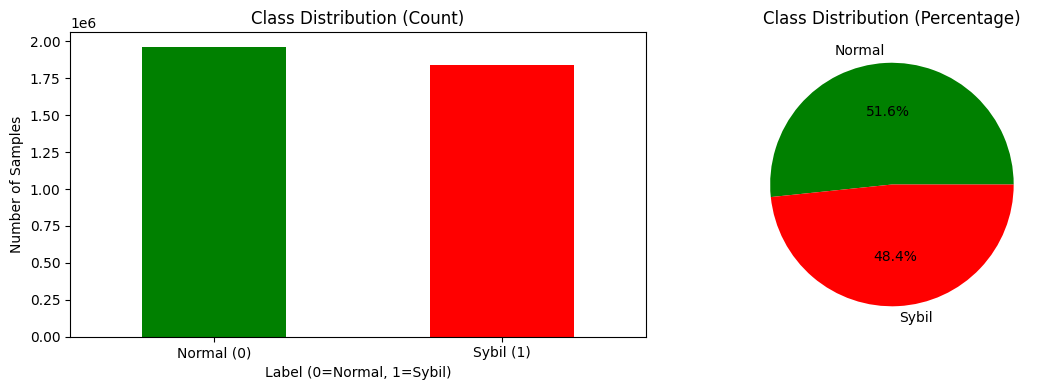

Class distribution visualization saved


In [37]:
# Plot class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot
class_dist.plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Class Distribution (Count)')
axes[0].set_xlabel('Label (0=Normal, 1=Sybil)')
axes[0].set_ylabel('Number of Samples')
axes[0].set_xticklabels(['Normal (0)', 'Sybil (1)'], rotation=0)

# Pie chart
y.value_counts().plot(kind='pie', ax=axes[1], labels=['Normal', 'Sybil'], autopct='%1.1f%%', colors=['green', 'red'])
axes[1].set_title('Class Distribution (Percentage)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('stage1_class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print("Class distribution visualization saved")

## Section 5: Split Data into Train and Test Sets

Split dataset using stratified split to maintain class distribution in both sets.

In [38]:
# Split data: 70% train, 30% test
# Use stratify to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y  # Maintains class distribution in both sets
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"\nTraining set class distribution:")
print(y_train.value_counts())
print(f"\nTest set class distribution:")
print(y_test.value_counts())
print(f"\nStratified split completed successfully")

Training set size: 2660732 samples
Test set size: 1140314 samples

Training set class distribution:
label
0    1374105
1    1286627
Name: count, dtype: int64

Test set class distribution:
label
0    588903
1    551411
Name: count, dtype: int64

Stratified split completed successfully


## Section 6: Feature Scaling

Standardize features to improve Logistic Regression performance.

**Why scale?** Logistic Regression performs better when features have similar scales.
StandardScaler centers features around 0 and scales to unit variance.

In [39]:
# Select only numeric columns for scaling
X_train_numeric = X_train.select_dtypes(include=[np.number])
X_test_numeric = X_test.select_dtypes(include=[np.number])

print(f"Features before filtering: {X_train.shape[1]}")
print(f"Numeric features selected: {X_train_numeric.shape[1]}")
if X_train.shape[1] > X_train_numeric.shape[1]:
    non_numeric_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()
    print(f"Non-numeric columns dropped: {non_numeric_cols}\n")

# Handle missing values - use mean imputation
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
X_train_numeric = pd.DataFrame(
    imputer.fit_transform(X_train_numeric),
    columns=X_train_numeric.columns
)
X_test_numeric = pd.DataFrame(
    imputer.transform(X_test_numeric),
    columns=X_test_numeric.columns
)

print(f"Missing values after imputation: {X_train_numeric.isnull().sum().sum()}\n")

# Initialize scaler
scaler = StandardScaler()

# Fit scaler on training data and transform both train and test
X_train_scaled = scaler.fit_transform(X_train_numeric)
X_test_scaled = scaler.transform(X_test_numeric)

print(f"Original feature range (first feature):")
print(f"   Min: {X_train_numeric.iloc[:, 0].min():.2f}")
print(f"   Max: {X_train_numeric.iloc[:, 0].max():.2f}")
print(f"   Mean: {X_train_numeric.iloc[:, 0].mean():.2f}")
print(f"\nScaled feature range (first feature):")
print(f"   Min: {X_train_scaled[:, 0].min():.2f}")
print(f"   Max: {X_train_scaled[:, 0].max():.2f}")
print(f"   Mean: {X_train_scaled[:, 0].mean():.4f}")
print(f"\n Features scaled successfully")

Features before filtering: 21
Numeric features selected: 19
Non-numeric columns dropped: ['node_id', 'node_mac']

Missing values after imputation: 0

Original feature range (first feature):
   Min: 0.00
   Max: 299999.00
   Mean: 142475.08

Scaled feature range (first feature):
   Min: -1.58
   Max: 1.75
   Mean: -0.0000

 Features scaled successfully


## Section 7: Train Logistic Regression Baseline

Train the simplest model to establish a performance baseline.

**Why Logistic Regression?**
- Simplest linear model
- Fast training and inference
- Provides interpretable coefficients
- Good baseline for comparison

In [40]:
print("Training Logistic Regression baseline...\n")

# Initialize Logistic Regression with balanced class weights
# class_weight='balanced' automatically adjusts weights inversely proportional to class frequency
# This helps handle the class imbalance (80% Normal, 20% Sybil)
lr = LogisticRegression(
    class_weight='balanced',  # Handle imbalanced classes
    max_iter=1000,            # Maximum iterations
    random_state=42,          # Reproducibility
    solver='liblinear'         # Good for small datasets
)

# Train the model
lr.fit(X_train_scaled, y_train)

print("Logistic Regression training completed")
print(f"\nModel coefficients (feature weights):")
coefficients = pd.DataFrame({
    'Feature': X_train_numeric.columns,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)
print(coefficients)
print(f"\nIntercept: {lr.intercept_[0]:.4f}")

Training Logistic Regression baseline...

Logistic Regression training completed

Model coefficients (feature weights):
              Feature  Coefficient
2                 pps     5.741071
11      udp_pkt_count     5.737634
12          rssi_mean     3.949988
7      seq_reset_rate     2.058503
17       rssi_missing     2.027564
16   rssi_frame_count     1.905829
15           rssi_max    -1.183405
8        dup_seq_rate     1.084395
5        seq_gap_mean    -0.567188
1        window_end_s    -0.564358
0      window_start_s    -0.564358
9   out_of_order_rate     0.361100
10   boot_change_rate    -0.342397
18            boot_id     0.336420
13           rssi_std     0.099801
3            iat_mean    -0.045794
14           rssi_min    -0.039853
4             iat_std     0.027273
6         seq_gap_max     0.021930

Intercept: 2.9871


## Section 8: Evaluate on Test Set

Evaluate baseline model performance on unseen test data.

In [41]:
# Make predictions
y_pred = lr.predict(X_test_scaled)
y_prob = lr.predict_proba(X_test_scaled)[:, 1]  # Probability of Sybil

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("="*60)
print("STAGE 1: BASELINE MODEL EVALUATION")
print("="*60)
print(f"\nAccuracy: {accuracy:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC:  {roc_auc:.4f}")
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Sybil']))
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

STAGE 1: BASELINE MODEL EVALUATION

Accuracy: 0.9974
F1-Score: 0.9973
ROC-AUC:  0.9987

Detailed Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    588903
       Sybil       1.00      1.00      1.00    551411

    accuracy                           1.00   1140314
   macro avg       1.00      1.00      1.00   1140314
weighted avg       1.00      1.00      1.00   1140314


Confusion Matrix:
[[588293    610]
 [  2330 549081]]


## Section 9: Cross-Validation

Perform 5-fold cross-validation to estimate model stability and generalization.

**Why cross-validation?** Provides more robust performance estimate than single train-test split.

In [42]:
print("Performing 5-fold cross-validation...\n")

# Perform cross-validation
cv_scores = cross_val_score(
    lr,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='f1'
)

print("Cross-Validation F1 Scores:")
for i, score in enumerate(cv_scores, 1):
    print(f"   Fold {i}: {score:.4f}")
print(f"\nMean F1-Score:  {cv_scores.mean():.4f}")
print(f"Std Deviation:  {cv_scores.std():.4f}")
print(f"Confidence Interval (95%): {cv_scores.mean():.4f} ± {1.96*cv_scores.std():.4f}")

Performing 5-fold cross-validation...

Cross-Validation F1 Scores:
   Fold 1: 0.9972
   Fold 2: 0.9972
   Fold 3: 0.9972
   Fold 4: 0.9974
   Fold 5: 0.9971

Mean F1-Score:  0.9972
Std Deviation:  0.0001
Confidence Interval (95%): 0.9972 ± 0.0001


## Section 10: Go/No-Go Decision

Determine if dataset quality is acceptable and proceed to Stage 2.

In [43]:
print("="*60)
print("STAGE 1: GO/NO-GO DECISION CRITERIA")
print("="*60)

# Decision criteria
f1_baseline = f1
go_no_go = "PASS" if f1_baseline > 0.70 else " FAIL" if f1_baseline < 0.60 else "WARN"
criteria_status = "" if f1_baseline > 0.70 else " (Dataset may have quality issues - review features)" if f1_baseline < 0.60 else " (Marginal - investigate features)"

print(f"\nF1-Score Baseline: {f1_baseline:.4f}")
print(f"Status: {go_no_go}{criteria_status}")

if f1_baseline > 0.70:
    print(f"\nDECISION: PROCEED TO STAGE 2")
    print(f"  Dataset is learnable with F1-score > 70%")
    print(f"  Ready to test faster models (Random Forest)")
elif f1_baseline < 0.60:
    print(f"\n DECISION: STOP - DEBUG DATASET")
    print(f"  F1-score < 60% indicates dataset quality issues")
    print(f"  Recommended actions:")
    print(f"    1. Check for missing/corrupted values")
    print(f"    2. Verify feature extraction logic")
    print(f"    3. Ensure correct label assignment")
    print(f"    4. Investigate feature distributions")
else:
    print(f"\nDECISION: CONDITIONAL PROCEED TO STAGE 2")
    print(f"  F1-score is marginal (60-70%)")
    print(f"  Investigate:")
    print(f"    1. Feature relevance and quality")
    print(f"    2. Class distribution balance")
    print(f"    3. Potential feature engineering needed")

STAGE 1: GO/NO-GO DECISION CRITERIA

F1-Score Baseline: 0.9973
Status: PASS

DECISION: PROCEED TO STAGE 2
  Dataset is learnable with F1-score > 70%
  Ready to test faster models (Random Forest)


## Section 11: Save Results

Save baseline results for reference in later stages.

In [44]:
# Save results to file
import pickle
import json

# Save scaled data for next stages
pickle.dump({
    'X_train_scaled': X_train_scaled,
    'X_test_scaled': X_test_scaled,
    'y_train': y_train,
    'y_test': y_test,
    'scaler': scaler,
    'X_columns': X_train_numeric.columns.tolist()
}, open('stage1_preprocessed_data.pkl', 'wb'))

# Save model
pickle.dump(lr, open('stage1_baseline_model.pkl', 'wb'))

# Save metrics
metrics = {
    'accuracy': float(accuracy),
    'f1_score': float(f1),
    'roc_auc': float(roc_auc),
    'cv_f1_mean': float(cv_scores.mean()),
    'cv_f1_std': float(cv_scores.std())
}
json.dump(metrics, open('stage1_baseline_results.json', 'w'), indent=2)

print("Results saved:")
print(f"  - stage1_preprocessed_data.pkl (scaled data for next stages)")
print(f"  - stage1_baseline_model.pkl (trained model)")
print(f"  - stage1_baseline_results.json (metrics)")

Results saved:
  - stage1_preprocessed_data.pkl (scaled data for next stages)
  - stage1_baseline_model.pkl (trained model)
  - stage1_baseline_results.json (metrics)


## Summary

1. Loaded and analyzed  dataset
2. Performed data quality checks
3. Visualized class distribution
4. Split and scaled data properly
5. Trained Logistic Regression baseline
6. Evaluated with multiple metrics
7. Validated with cross-validation
8. Made go/no-go decision

**Next Step:** If F1 > 70%, proceed to **Stage 2: Fast Models Comparison**

In Stage 2 will:
- Test Random Forest on the same data
- Compare speed vs accuracy
- Identify best fast model for real-time deployment